<div style=" padding:5px; border-radius:2.5px;">
<h1>Task 2: Credit Risk Prediction</h1><h3>Dataset(loan_default_prediction)</h3>
<div>
<p>According to given instruction, I have to <li>Handle missing data appropriately.</li>
<li>Visualize key features such as loan_amount, education/employment_status, and income.</li>
<li>Train a classification model like Logistic Regression or Decision Tree.</li>
<li>Evaluate the model using accuracy and a confusion matrix.</li>
</div>
<div><p style="font-size:18px;"><h2>Summary</h2>
The main objective focuses on predicting whether a loan applicant is likely to default using machine learning.
With increasing loan applications, it has become important for banks to make fast, accurate, and data-driven decisions. This project aims to build a predictive model using historical applicant data such as income, loan_amount and employment_status. By analyzing these features, the model helps improving loan approval decisions and reducing financial losses.</p>
</div>
</div>

In [88]:
# importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
# loading dataset
data=pd.read_csv("loan_default_prediction.csv")
print("\nComplete structure of dataset:")
print(data)
print("\nFirst 5 Rows:")
print(data.head())


Complete structure of dataset:
    loan_id  income  loan_amount employment_status  default
0     L1000    9270        22969          Employed        1
1     L1001    2860        46659          Employed        0
2     L1002    7390        38545        Unemployed        1
3     L1003    7191        37668          Employed        0
4     L1004   13964        24061          Employed        0
..      ...     ...          ...               ...      ...
995   L1995    8777         4762        Unemployed        1
996   L1996   13314        47167        Unemployed        1
997   L1997    9570        10768          Employed        1
998   L1998    9956        44408          Employed        0
999   L1999    7124        40499        Unemployed        1

[1000 rows x 5 columns]

First 5 Rows:
  loan_id  income  loan_amount employment_status  default
0   L1000    9270        22969          Employed        1
1   L1001    2860        46659          Employed        0
2   L1002    7390        38545    

<h2>Handling missing values and preprocessing</h2>

<p>loan_id column is not necessary for our prediction. so, we remove this column first</p>

In [89]:
#remove loan_id col using drop()function
data.drop('loan_id',axis=1, inplace=True)

In [90]:
data.isnull().sum().sort_values(ascending=False)

income               0
loan_amount          0
employment_status    0
default              0
dtype: int64

### We can see that there is no missing value in our dataset

In [91]:
#encoding employment_status column to numeric
data['employment_status'] = data['employment_status'].map({'Employed':1,'Unemployed':0})
data.head()

,income,loan_amount,employment_status,default
0,9270,22969,1,1
1,2860,46659,1,0
2,7390,38545,0,1
3,7191,37668,1,0
4,13964,24061,1,0


<h2>Visualization</h2>

<h4>Pie chart</h4>
<p>This pie chart shows the percentage of loan defaulters and non-defaulters in dataset.</p>

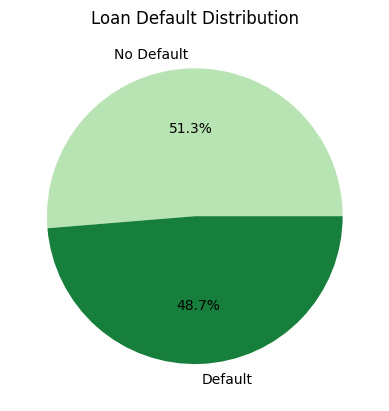

In [92]:
colors =plt.cm.Greens([0.3,0.8])
data['default'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=colors,
    labels=['No Default', 'Default']
)
plt.title("Loan Default Distribution")
plt.ylabel("")
plt.show()

<h4>Count plot</h4>
<p>This plot shows how employment_status affects loan default behaviour.</p>

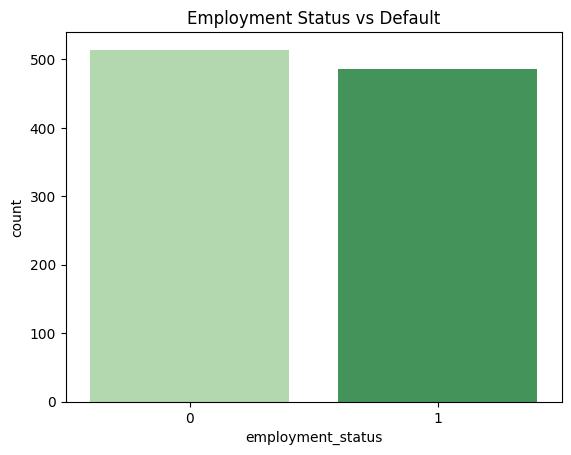

In [93]:
sns.countplot(x="employment_status", data=data, palette="Greens")
plt.title("Employment Status vs Default")
plt.show()

<h4>Box plot</h4>
<p>This boxplot shows how income differs between people who default and those who do not default, helping us understand risk patterns.</p>

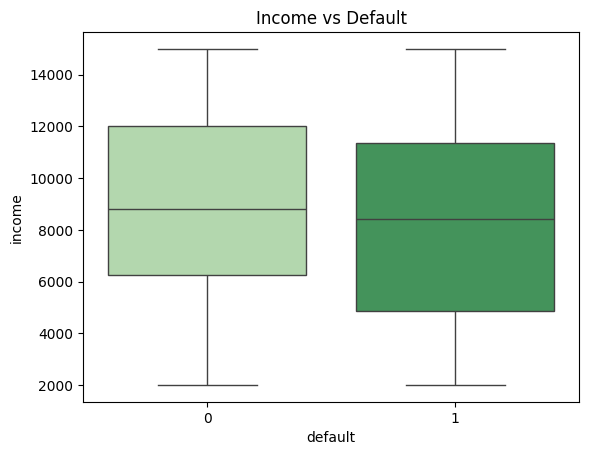

In [94]:
sns.boxplot(x="default", y="income", data=data, palette="Greens")
plt.title("Income vs Default")
plt.show()

<h4>Heat map</h4>

<p>The correlation heatmap shows that income has a negative relationship with loan default, indicating that higher income reduces the likelihood of default. Loan amount has a positive relationship with default, suggesting that higher loan amounts increase default risk.</p>

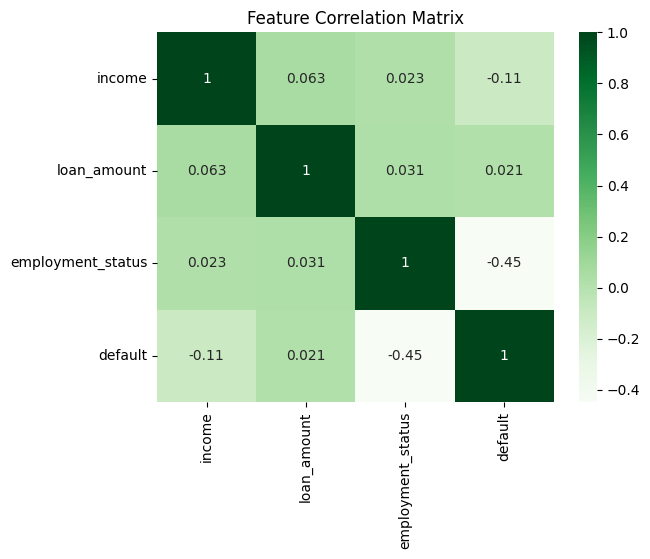

In [95]:
sns.heatmap(data.corr(), annot=True, cmap='Greens')
plt.title("Feature Correlation Matrix")
plt.show()

<h4>Line bar</h4>
<p>Line bar clearly shows that default increses if the employment rate is increased</p>

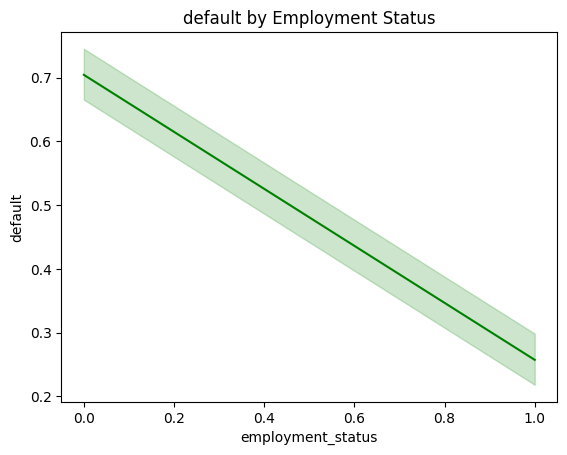

In [96]:
sns.lineplot(x="employment_status", y="default", data=data, color="green")
plt.title("default by Employment Status")
plt.show()

<h2>Classification Model</h2>
<p>We use LogisticRegression with max_2000 iterations because our problem is of binary classification and we see that we will get better accuracy in our model rather than DecisionTreeClassifier.</p>

In [97]:
X = data[['income','loan_amount','employment_status']]
y = data['default']
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

<h3>Feature Scalling/Standard Scalling</h3>

In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:

#load/call the logistic regression model
model = LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")
#train the model
model.fit(X_train_scaled, y_train)
#model.predict(X_test)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


In [100]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[1 0 1 0 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 0 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0
 1 0 1 1 1 1 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 1
 1 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 1
 1 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 1 0 1 1 0 0 1 1 0
 0 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 1 1 1 1 1 1 0 0 0 0 1 0 0 1
 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1]


### Prediction for unknown values

In [102]:
#lets predict for known values
print(model.predict([[7390,38545,0]]))

[1]


In [103]:
#lets predict for unknown values
print(model.predict([[8000,40000,1]]))

[1]


<h2>Evaluation of Model</h2>
<h4>Accuracy_score</h4>

In [105]:
# Checking accuracy score.
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.785


<p>We can see that accuracy score is 78%</p>

<h4>Confusion Matrix</h4>
<p>Confusion matrix checks how many predictions are correct and incorrect</p>

In [106]:
# For confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[76 27]
 [16 81]]


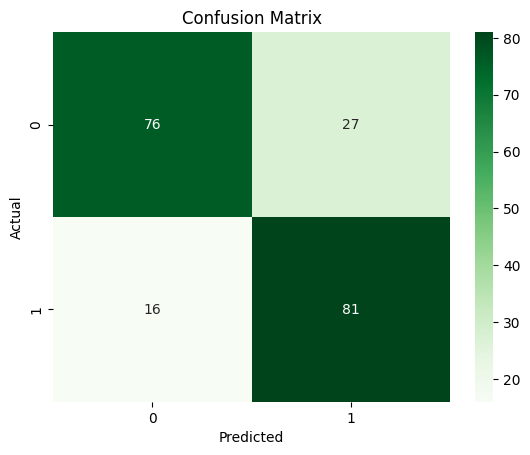

In [107]:
#Graphical representation of confusion matrix by heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<h2>Classification_report</h2>

In [108]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.785
Confusion Matrix:
 [[76 27]
 [16 81]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.74      0.78       103
           1       0.75      0.84      0.79        97

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.78       200
weighted avg       0.79      0.79      0.78       200



<h2>Conclusion</h2>
<p>The dataset was preprocessed by encoding categorical variables and applying feature scaling using StandardScaler. A Logistic Regression model was trained to predict loan default risk. Stratified sampling was used during the train-test split to maintain class distribution, which improved model performance.
The final model achieved an accuracy of 78.5%, indicating that the model correctly predicts the loan default status for the majority of cases. Evaluation using a confusion matrix and classification report showed that the model performs reasonably well in identifying both defaulters and non-defaulters.</p>